# Final Proje — Erken Alzheimer Teşhisi (5 Model Karşılaştırma)

**Medikal Görüntü İşleme — Dönem Projesi**

Bu notebook, dersin teknik ödevlerini tek bir uçtan-uca hatta birleştirir ve
**5 farklı derin öğrenme mimarisi** ile sınıflandırma performansını karşılaştırır.

| Bölüm | Ödev karşılığı |
|-------|----------------|
| Görüntü işleme galerisi (CLAHE, histogram eşitleme, Sobel/Canny, morfoloji) | **Ödev 3** |
| Otsu tabanlı beyin segmentasyonu (maske + 3 doku) | **Ödev 4** |
| Albumentations augmentasyon (sınıf dengeleme) | **Ödev 5** |
| El-yapımı özellik (HoG/SIFT/GLCM) + Random Forest baseline | **Ödev 6** |
| **5 Model:** ResNet18, VGG16, DenseNet121, EfficientNet-B0, MobileNetV3 + Grad-CAM + ROC | Final |

> **Kullanılan Mimariler:** ImageNet ön-eğitimli **ResNet18**, **VGG16**, **DenseNet121**,
> **EfficientNet-B0** ve **MobileNetV3-Large** transfer learning ile MR görüntülerinden
> derin özellik çıkarılır ve 4 sınıf ayırt edilir: `Mild_Demented`, `Moderate_Demented`,
> `Non_Demented`, `Very_Mild_Demented`.

## 0. Kurulum ve Yapılandırma

In [1]:
import io, time, random, warnings, gc
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision.models import (
    resnet18, ResNet18_Weights,
    vgg16, VGG16_Weights,
    densenet121, DenseNet121_Weights,
    efficientnet_b0, EfficientNet_B0_Weights,
    mobilenet_v3_large, MobileNet_V3_Large_Weights,
)

import albumentations as A
from skimage.feature import hog, graycomatrix, graycoprops
from skimage.filters import threshold_multiotsu
from scipy.stats import skew, kurtosis
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, accuracy_score, confusion_matrix,
                             roc_curve, auc, precision_recall_fscore_support)

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# --- YOL AYARLARI (relative path — bu repo içinde çalışır) ---
DATA_DIR   = Path("../data")
OUTPUT_DIR = Path("../outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# --- CİHAZ AYARI (GPU varsa kullan) ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.backends.cudnn.deterministic = True

CLASS_NAMES = ["Mild_Demented", "Moderate_Demented", "Non_Demented", "Very_Mild_Demented"]
NUM_CLASSES = len(CLASS_NAMES)
IMG_SIZE = 128

IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32).reshape(3, 1, 1)
IMAGENET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32).reshape(3, 1, 1)

# Eğitim parametreleri
TARGET_PER_CLASS = 400   # Augmentasyon ile sınıf başına hedef örnek
RAW_CAP          = 400   # Orijinal örnek üst sınırı
FT_EPOCHS        = 15    # Fine-tuning epoch sayısı
RF_PER_CLASS     = 200   # Random Forest için sınıf başına örnek
BATCH_SIZE_TRAIN = 16    # GPU bellek dostu batch size
BATCH_SIZE_TEST  = 32

print("PyTorch", torch.__version__, "| cihaz:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM:", round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 1), "GB")

PyTorch 2.11.0+cu128 | cihaz: cuda
GPU: NVIDIA GeForce RTX 3050 Ti Laptop GPU
VRAM: 4.0 GB


## 1. Veri Yükleme

In [2]:
TRAIN_PATH = DATA_DIR / "train-00000-of-00001-c08a401c53fe5312.parquet"
TEST_PATH  = DATA_DIR / "test-00000-of-00001-44110b9df98c5585.parquet"
train_df = pd.read_parquet(TRAIN_PATH)
test_df  = pd.read_parquet(TEST_PATH)

def decode_image(cell):
    return np.array(Image.open(io.BytesIO(cell["bytes"])).convert("L"))

# Veri setinin orijinal train/test bölünmesi kullanılır
pool_cells  = list(train_df["image"]) + list(test_df["image"])
pool_labels = np.concatenate([train_df["label"].to_numpy(), test_df["label"].to_numpy()])
pool_gray   = [decode_image(c) for c in pool_cells]
n_tr = len(train_df)
train_idx = np.arange(n_tr)
test_idx  = np.arange(n_tr, len(pool_gray))

print(f"Train: {len(train_idx)} | Test: {len(test_idx)} | boyut {pool_gray[0].shape}")
print("Train/sinif:", {CLASS_NAMES[i]: int((pool_labels[train_idx]==i).sum()) for i in range(NUM_CLASSES)})
print("Test /sinif:", {CLASS_NAMES[i]: int((pool_labels[test_idx]==i).sum()) for i in range(NUM_CLASSES)})

Train: 5120 | Test: 1280 | boyut (128, 128)
Train/sinif: {'Mild_Demented': 724, 'Moderate_Demented': 49, 'Non_Demented': 2566, 'Very_Mild_Demented': 1781}
Test /sinif: {'Mild_Demented': 172, 'Moderate_Demented': 15, 'Non_Demented': 634, 'Very_Mild_Demented': 459}


## 2. Keşifsel Veri Analizi (EDA)

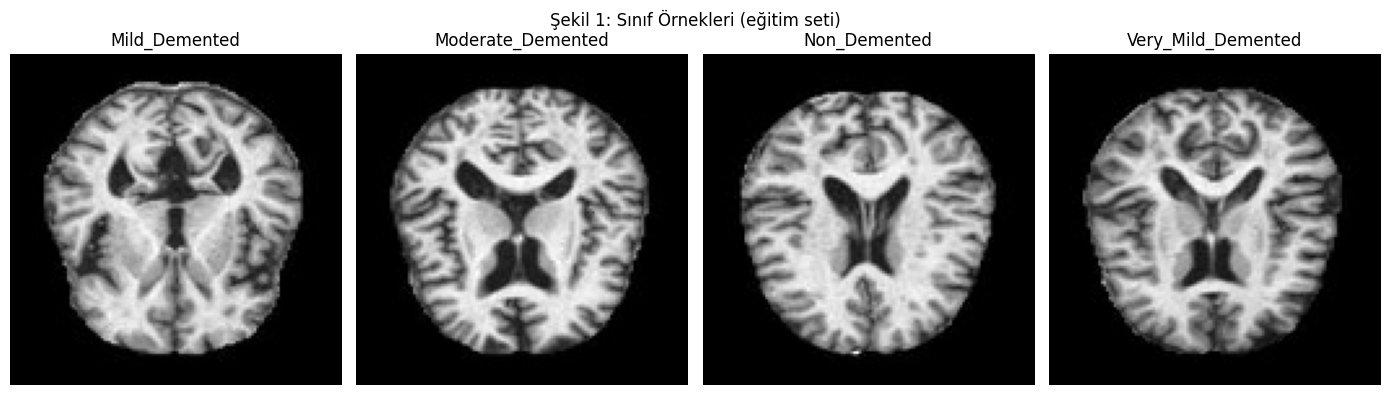

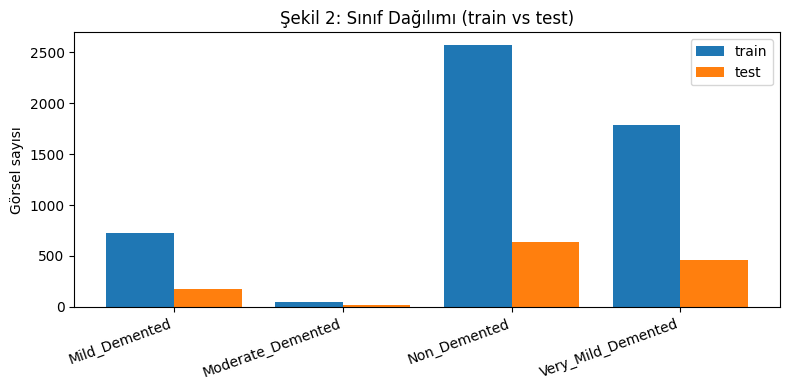

In [3]:
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(14, 4))
for ax, c in zip(axes, range(NUM_CLASSES)):
    i = train_idx[np.where(pool_labels[train_idx] == c)[0][0]]
    ax.imshow(pool_gray[i], cmap="gray"); ax.set_title(CLASS_NAMES[c]); ax.axis("off")
plt.suptitle("Şekil 1: Sınıf Örnekleri (eğitim seti)"); plt.tight_layout()
plt.savefig(OUTPUT_DIR / "b_eda_samples.png", dpi=130, bbox_inches="tight"); plt.show()

tr_counts = [int((pool_labels[train_idx]==i).sum()) for i in range(NUM_CLASSES)]
te_counts = [int((pool_labels[test_idx]==i).sum()) for i in range(NUM_CLASSES)]
x = np.arange(NUM_CLASSES); w = 0.4
plt.figure(figsize=(8, 4))
plt.bar(x-w/2, tr_counts, w, label="train"); plt.bar(x+w/2, te_counts, w, label="test")
plt.xticks(x, CLASS_NAMES, rotation=20, ha="right"); plt.ylabel("Görsel sayısı")
plt.title("Şekil 2: Sınıf Dağılımı (train vs test)"); plt.legend(); plt.tight_layout()
plt.savefig(OUTPUT_DIR / "b_eda_distribution.png", dpi=130, bbox_inches="tight"); plt.show()

## 3. Görüntü İşleme Galerisi (Ödev 3)

Kontrast iyileştirme (Histogram Eşitleme, CLAHE), gürültü azaltma (Gaussian) ve kenar/morfoloji
(Sobel, Canny, Laplacian, morfolojik gradyan) — beyin MR ön-işlemenin temel teknikleri.

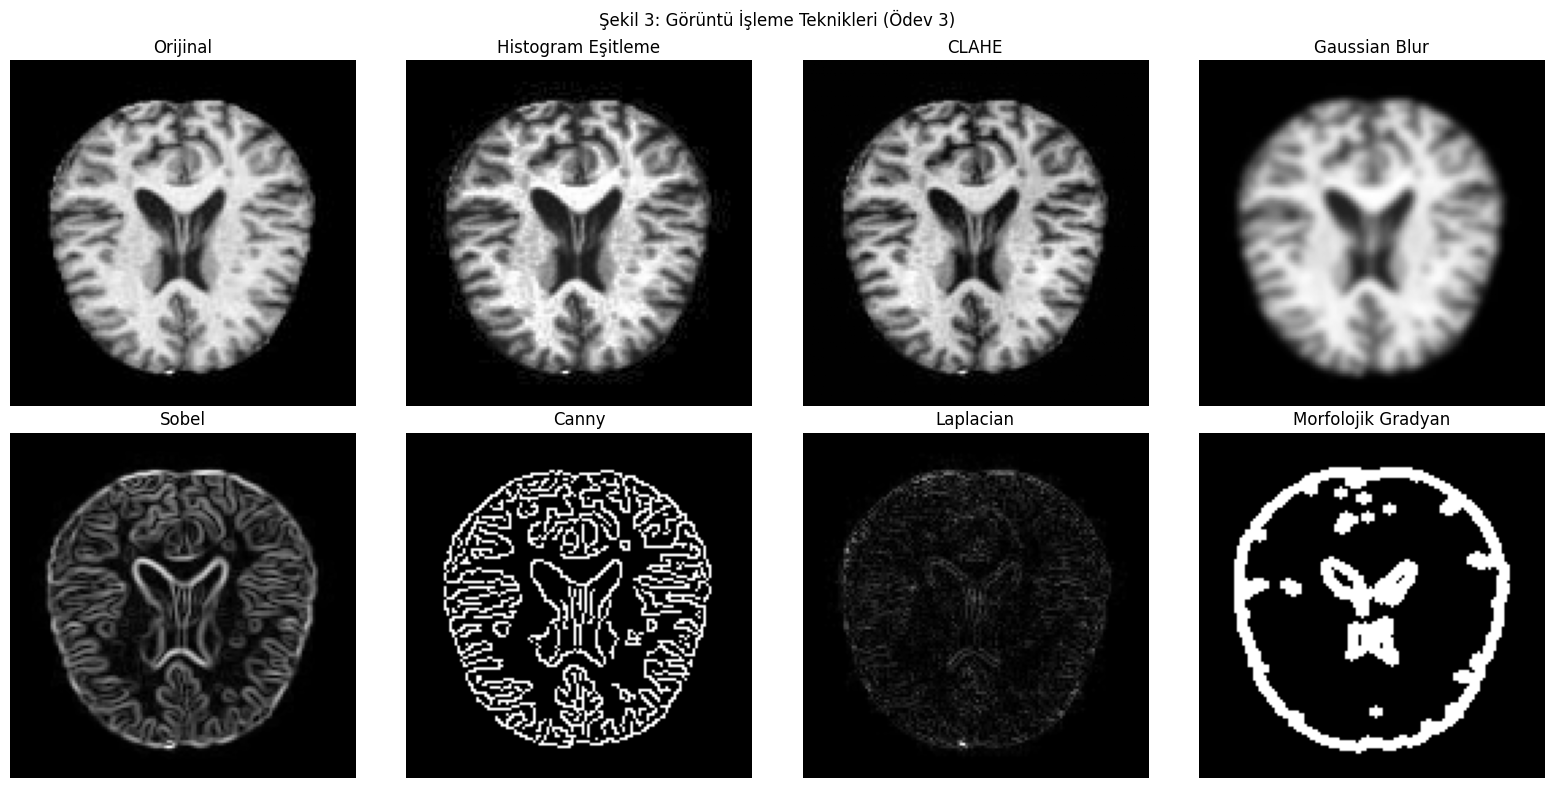

In [4]:
s = pool_gray[train_idx[0]]
_clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
sx = cv2.Sobel(s, cv2.CV_64F, 1, 0, ksize=3); sy = cv2.Sobel(s, cv2.CV_64F, 0, 1, ksize=3)
_, binimg = cv2.threshold(s, 30, 255, cv2.THRESH_BINARY)
kern = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))

row1 = [(s, "Orijinal"), (cv2.equalizeHist(s), "Histogram Eşitleme"),
        (_clahe.apply(s), "CLAHE"), (cv2.GaussianBlur(s, (5, 5), 1.5), "Gaussian Blur")]
row2 = [(np.sqrt(sx**2 + sy**2), "Sobel"), (cv2.Canny(s, 50, 150), "Canny"),
        (np.abs(cv2.Laplacian(s, cv2.CV_64F)), "Laplacian"),
        (cv2.morphologyEx(binimg, cv2.MORPH_GRADIENT, kern), "Morfolojik Gradyan")]
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, (im, t) in zip(axes[0], row1): ax.imshow(im, cmap="gray"); ax.set_title(t); ax.axis("off")
for ax, (im, t) in zip(axes[1], row2): ax.imshow(im, cmap="gray"); ax.set_title(t); ax.axis("off")
plt.suptitle("Şekil 3: Görüntü İşleme Teknikleri (Ödev 3)"); plt.tight_layout()
plt.savefig(OUTPUT_DIR / "b_gallery.png", dpi=130, bbox_inches="tight"); plt.show()

## 4. Otsu Tabanlı Segmentasyon (Ödev 4)

CLAHE+Blur → Otsu ile beyin maskesi (en büyük bileşen + morfoloji) → Multi-Otsu ile 3 doku
sınıfı (CSF / gri madde / beyaz madde benzeri).

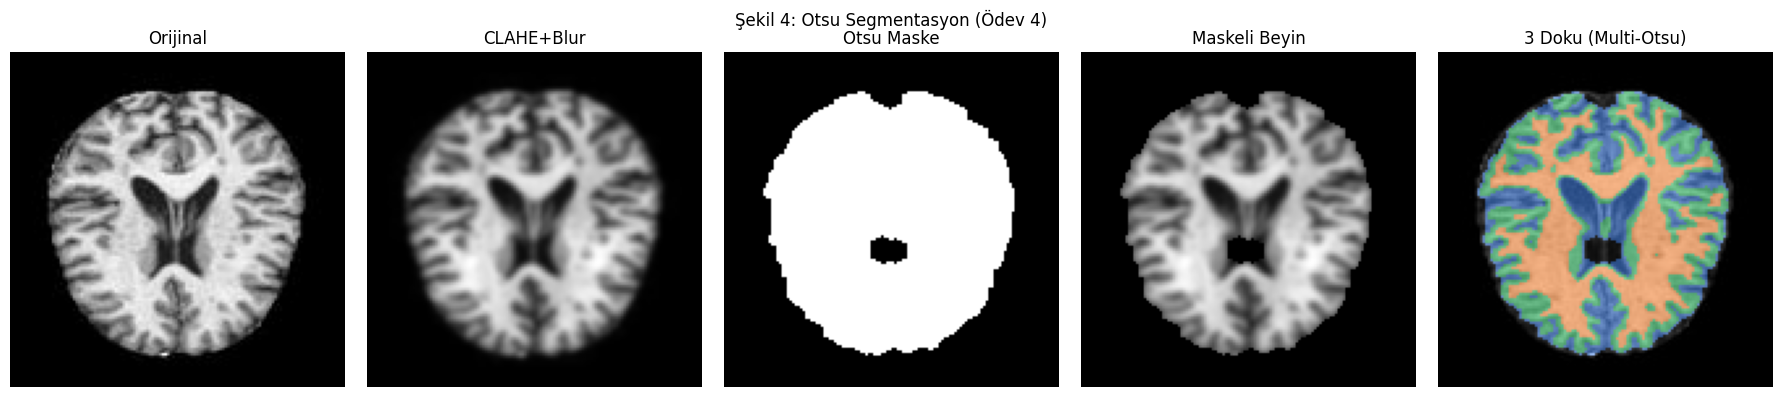

In [5]:
def preprocess_clahe(gray):
    return cv2.GaussianBlur(_clahe.apply(gray), (5, 5), 0)

def segment_brain_otsu(pre):
    _, mask = cv2.threshold(pre, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    n, lab, stats, _ = cv2.connectedComponentsWithStats(mask, 8)
    if n > 1:
        largest = 1 + int(np.argmax(stats[1:, cv2.CC_STAT_AREA]))
        mask = np.where(lab == largest, 255, 0).astype(np.uint8)
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k, iterations=2)
    return cv2.morphologyEx(mask, cv2.MORPH_OPEN, k, iterations=1)

def tissue_overlay(pre, mask):
    inside = mask > 0
    th = threshold_multiotsu(pre[inside], classes=3)
    tmap = np.digitize(pre, bins=th)
    colors = np.array([[59,130,246],[34,197,94],[249,115,22]], np.uint8)
    ov = np.zeros((*pre.shape, 3), np.uint8); ov[inside] = colors[tmap[inside]]
    return ov

g = pool_gray[train_idx[0]]
pre = preprocess_clahe(g); mask = segment_brain_otsu(pre)
masked = cv2.bitwise_and(pre, pre, mask=mask); ov = tissue_overlay(pre, mask)
panel = [(g, "Orijinal"), (pre, "CLAHE+Blur"), (mask, "Otsu Maske"), (masked, "Maskeli Beyin")]
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, (im, t) in zip(axes[:4], panel): ax.imshow(im, cmap="gray"); ax.set_title(t); ax.axis("off")
axes[4].imshow(g, cmap="gray"); axes[4].imshow(ov, alpha=0.5)
axes[4].set_title("3 Doku (Multi-Otsu)"); axes[4].axis("off")
plt.suptitle("Şekil 4: Otsu Segmentasyon (Ödev 4)"); plt.tight_layout()
plt.savefig(OUTPUT_DIR / "b_segmentation.png", dpi=130, bbox_inches="tight"); plt.show()

## 5. Veri Hazırlama: CLAHE + Augmentasyon (Ödev 5)

Modele **CLAHE ile iyileştirilmiş** görüntüler verilir. Eğitim seti, az örnekli sınıflar
augmentasyonla hedef sayıya tamamlanarak **dengelenir**.

Train: (1600, 128, 128) dağılım [400 400 400 400]
Test : (1280, 128, 128) dağılım [172  15 634 459]


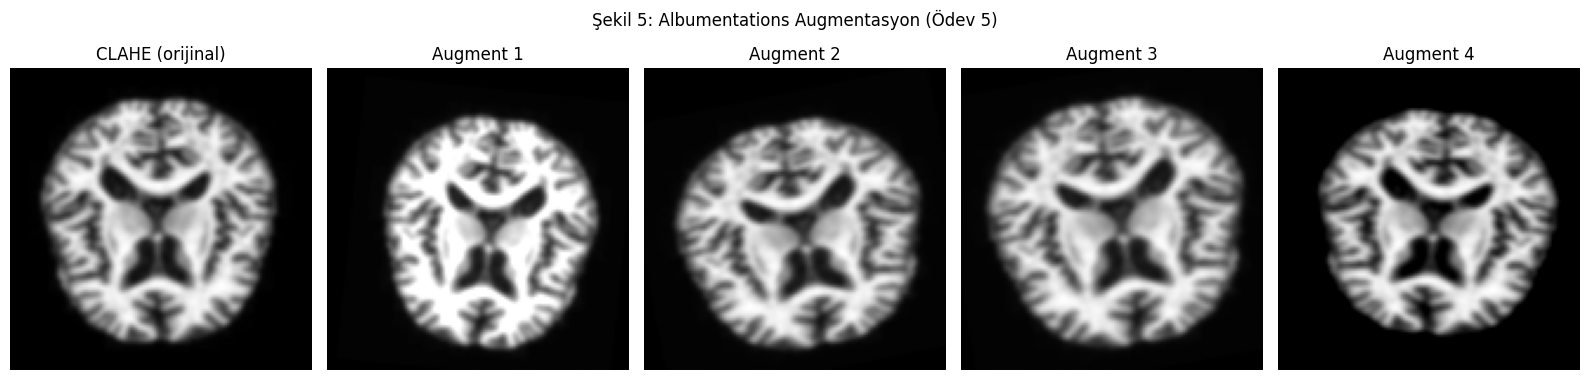

In [6]:
def clahe_img(gray):
    return cv2.resize(preprocess_clahe(gray), (IMG_SIZE, IMG_SIZE))

aug = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Affine(scale=(0.9, 1.1), translate_percent=(0.0, 0.06), rotate=(-12, 12), p=0.8),
    A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.5),
])

def build_train(target_per_class, raw_cap):
    rng = np.random.default_rng(SEED); imgs, labels = [], []
    for c in range(NUM_CLASSES):
        idx = train_idx[pool_labels[train_idx] == c].copy(); rng.shuffle(idx)
        base = [clahe_img(pool_gray[i]) for i in idx[:min(raw_cap, len(idx))]]
        for im in base: imgs.append(im); labels.append(c)
        for j in range(max(0, target_per_class - len(base))):
            imgs.append(aug(image=base[j % len(base)])["image"]); labels.append(c)
    return np.array(imgs), np.array(labels)

train_imgs, train_labels = build_train(TARGET_PER_CLASS, RAW_CAP)
test_imgs  = np.array([clahe_img(pool_gray[i]) for i in test_idx])
test_labels = pool_labels[test_idx]
print("Train:", train_imgs.shape, "dağılım", np.bincount(train_labels, minlength=NUM_CLASSES))
print("Test :", test_imgs.shape, "dağılım", np.bincount(test_labels, minlength=NUM_CLASSES))

base = clahe_img(pool_gray[train_idx[pool_labels[train_idx]==1][0]])
fig, axes = plt.subplots(1, 5, figsize=(16, 4))
axes[0].imshow(base, cmap="gray"); axes[0].set_title("CLAHE (orijinal)"); axes[0].axis("off")
for i in range(1, 5):
    axes[i].imshow(aug(image=base)["image"], cmap="gray"); axes[i].set_title(f"Augment {i}"); axes[i].axis("off")
plt.suptitle("Şekil 5: Albumentations Augmentasyon (Ödev 5)"); plt.tight_layout()
plt.savefig(OUTPUT_DIR / "b_augment.png", dpi=130, bbox_inches="tight"); plt.show()

## 6. Klasik Baseline (Ödev 6): El-Yapımı Özellikler + Random Forest

HoG + Intensity istatistikleri + SIFT + GLCM-Texture birleştirilip sınıf-ağırlıklı bir
Random Forest ile sınıflandırılır. CNN modelleri için karşılaştırma referansı.

In [7]:
def _f01(u8): return u8.astype(np.float32) / 255.0
def feat_hog(u8):
    return hog(_f01(u8), orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2))
def feat_intensity(u8):
    p = _f01(u8).flatten()
    return np.array([p.mean(), p.std(), skew(p), kurtosis(p), -np.sum(p*np.log2(p+1e-7))])
_sift = cv2.SIFT_create()
def feat_sift(u8):
    _, des = _sift.detectAndCompute(u8, None)
    return np.mean(des, axis=0) if des is not None else np.zeros(128)
def feat_glcm(u8):
    glcm = graycomatrix(u8, [1], [0, np.pi/4, np.pi/2], levels=256, symmetric=True, normed=True)
    return np.array([graycoprops(glcm, p).mean() for p in ["contrast","homogeneity","energy","correlation"]])
def extract_all(imgs):
    return np.array([np.concatenate([feat_hog(im), feat_intensity(im), feat_sift(im), feat_glcm(im)]) for im in imgs])

rng = np.random.default_rng(SEED); keep = []
for c in range(NUM_CLASSES):
    ci = np.where(train_labels == c)[0]; rng.shuffle(ci); keep += ci[:min(RF_PER_CLASS, len(ci))].tolist()
keep = np.array(keep)

t0 = time.time()
Xtr = extract_all(train_imgs[keep]); Xte = extract_all(test_imgs)
sc = StandardScaler(); Xtr_s = sc.fit_transform(Xtr); Xte_s = sc.transform(Xte)
rf = RandomForestClassifier(n_estimators=400, min_samples_leaf=2, class_weight="balanced",
                            n_jobs=-1, random_state=SEED)
rf.fit(Xtr_s, train_labels[keep])
rf_pred = rf.predict(Xte_s); rf_acc = accuracy_score(test_labels, rf_pred)
rf_prec, rf_rec, rf_f1, _ = precision_recall_fscore_support(test_labels, rf_pred, average="macro")
print(f"RF baseline doğruluk: {rf_acc:.4f}  (süre {time.time()-t0:.1f}s)")
print(classification_report(test_labels, rf_pred, target_names=CLASS_NAMES))

RF baseline doğruluk: 0.5789  (süre 52.9s)
                    precision    recall  f1-score   support

     Mild_Demented       0.36      0.63      0.45       172
 Moderate_Demented       1.00      0.13      0.24        15
      Non_Demented       0.70      0.67      0.68       634
Very_Mild_Demented       0.56      0.45      0.50       459

          accuracy                           0.58      1280
         macro avg       0.65      0.47      0.47      1280
      weighted avg       0.61      0.58      0.58      1280



## 7. Derin Öğrenme Modelleri — 5 Farklı Mimari

ImageNet ön-eğitimli 5 farklı CNN mimarisi transfer learning ile kullanılır.
Her modelde son katman(lar) ve son blok ince ayarlanır (fine-tuning).

**Kullanılan Mimariler:**
1. **ResNet18** [1] — Residual bağlantılar ile derin ağ eğitimini kolaylaştırır
2. **VGG16** [2] — Klasik derin CNN, ardışık konvolüsyon blokları
3. **DenseNet121** [3] — Dense bağlantılar, özellik tekrar kullanımı
4. **EfficientNet-B0** [4] — Compound scaling ile optimize edilmiş mimari
5. **MobileNetV3-Large** [5] — Depthwise separable konvolüsyonlar, hafif ve hızlı

### Hiperparametre Seçimi
- **Öğrenme oranı (lr=1e-4):** Transfer learning için düşük lr önerilir; ön-eğitimli ağırlıkları bozmadan ince ayar yapar.
- **Epoch sayısı (15):** GPU ile hızlı eğitim; early stopping mantığı ile en iyi model kaydedilir.
- **Batch size (16):** 4GB VRAM sınırına uygun; gradient noise da regularizasyona yardımcı olur.
- **Dropout (0.4-0.5):** Overfitting'i önlemek için; küçük veri setlerinde kritik.
- **Sınıf-ağırlıklı kayıp:** Dengesiz sınıf dağılımını telafi eder (Moderate_Demented çok az örnekli).

In [8]:
def to_tensor(u8):
    x = np.stack([u8.astype(np.float32)/255.0]*3, axis=0)
    return torch.from_numpy((x - IMAGENET_MEAN) / IMAGENET_STD).float()

class MRIDataset(Dataset):
    def __init__(self, imgs, labels, augment):
        self.imgs, self.labels, self.augment = imgs, labels, augment
    def __len__(self): return len(self.imgs)
    def __getitem__(self, i):
        im = self.imgs[i]
        if self.augment: im = aug(image=im)["image"]
        return to_tensor(im), int(self.labels[i])

# Train/Val/Test split
tr_i, val_i = train_test_split(np.arange(len(train_labels)), test_size=0.2,
                               random_state=SEED, stratify=train_labels)
train_loader = DataLoader(MRIDataset(train_imgs[tr_i], train_labels[tr_i], True),
                          batch_size=BATCH_SIZE_TRAIN, shuffle=True)
val_loader   = DataLoader(MRIDataset(train_imgs[val_i], train_labels[val_i], False),
                          batch_size=BATCH_SIZE_TEST)
test_loader  = DataLoader(MRIDataset(test_imgs, test_labels, False),
                          batch_size=BATCH_SIZE_TEST)

def build_model(name):
    """5 farklı ImageNet ön-eğitimli CNN mimarisi oluşturur."""
    if name == "ResNet18":
        model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
        model.fc = nn.Sequential(nn.Dropout(0.4), nn.Linear(512, NUM_CLASSES))
        for p in model.parameters(): p.requires_grad = False
        for p in model.layer4.parameters(): p.requires_grad = True
        for p in model.fc.parameters(): p.requires_grad = True

    elif name == "VGG16":
        model = vgg16(weights=VGG16_Weights.IMAGENET1K_V1)
        model.classifier[6] = nn.Sequential(nn.Dropout(0.5), nn.Linear(4096, NUM_CLASSES))
        for p in model.parameters(): p.requires_grad = False
        for p in model.classifier.parameters(): p.requires_grad = True

    elif name == "DenseNet121":
        model = densenet121(weights=DenseNet121_Weights.IMAGENET1K_V1)
        model.classifier = nn.Sequential(nn.Dropout(0.4), nn.Linear(1024, NUM_CLASSES))
        for p in model.parameters(): p.requires_grad = False
        for m in [model.features.denseblock4, model.features.norm5, model.classifier]:
            for p in m.parameters(): p.requires_grad = True

    elif name == "EfficientNet-B0":
        model = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
        model.classifier = nn.Sequential(nn.Dropout(0.4), nn.Linear(1280, NUM_CLASSES))
        for p in model.parameters(): p.requires_grad = False
        for p in model.features[-1].parameters(): p.requires_grad = True
        for p in model.classifier.parameters(): p.requires_grad = True

    elif name == "MobileNetV3":
        model = mobilenet_v3_large(weights=MobileNet_V3_Large_Weights.IMAGENET1K_V1)
        model.classifier[3] = nn.Linear(1280, NUM_CLASSES)
        for p in model.parameters(): p.requires_grad = False
        for p in model.features[-1].parameters(): p.requires_grad = True
        for p in model.classifier.parameters(): p.requires_grad = True

    else:
        raise ValueError(f"Bilinmeyen model: {name}")

    n_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
    n_total = sum(p.numel() for p in model.parameters())
    print(f"  Eğitilebilir: {n_train:,} / Toplam: {n_total:,} parametre")
    return model.to(DEVICE)

MODEL_NAMES = ["ResNet18", "VGG16", "DenseNet121", "EfficientNet-B0", "MobileNetV3"]
print("Tanımlanan modeller:", MODEL_NAMES)

Tanımlanan modeller: ['ResNet18', 'VGG16', 'DenseNet121', 'EfficientNet-B0', 'MobileNetV3']


## 8. Tüm Modellerin Eğitimi

In [9]:
def run_epoch(model, loader, criterion, opt, train):
    model.train() if train else model.eval()
    torch.set_grad_enabled(train)
    loss_sum, tot, ys, ps = 0.0, 0, [], []
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        if train: opt.zero_grad()
        out = model(xb); loss = criterion(out, yb)
        if train: loss.backward(); opt.step()
        loss_sum += loss.item()*len(yb); tot += len(yb)
        ys.append(yb.cpu().numpy()); ps.append(out.argmax(1).detach().cpu().numpy())
    torch.set_grad_enabled(True)
    y, p = np.concatenate(ys), np.concatenate(ps)
    return loss_sum/tot, accuracy_score(y, p)

def evaluate_model(model, loader):
    """Test seti üzerinde değerlendirme yapar."""
    model.eval(); ys, ps, probs = [], [], []
    with torch.no_grad():
        for xb, yb in loader:
            out = model(xb.to(DEVICE))
            probs.append(torch.softmax(out, 1).cpu().numpy())
            ps.append(out.argmax(1).cpu().numpy()); ys.append(yb.numpy())
    y_true = np.concatenate(ys); pred = np.concatenate(ps); prob = np.concatenate(probs)
    acc = accuracy_score(y_true, pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, pred, average="macro")
    cm = confusion_matrix(y_true, pred)
    return {"y_true": y_true, "pred": pred, "prob": prob,
            "accuracy": acc, "precision": prec, "recall": rec, "f1": f1, "cm": cm}

# Sınıf ağırlıkları
cls_counts = np.bincount(train_labels, minlength=NUM_CLASSES).astype(np.float64)
cls_w = torch.tensor(cls_counts.sum()/(NUM_CLASSES*cls_counts), dtype=torch.float32).to(DEVICE)

all_results = {}
all_histories = {}

for model_name in MODEL_NAMES:
    print(f"\n{'='*60}")
    print(f"  Model: {model_name}")
    print(f"{'='*60}")

    model = build_model(model_name)
    criterion = nn.CrossEntropyLoss(weight=cls_w)
    opt = torch.optim.Adam([p for p in model.parameters() if p.requires_grad],
                           lr=1e-4, weight_decay=1e-4)

    hist = {"tr_loss": [], "val_loss": [], "tr_acc": [], "val_acc": []}
    best_val, best_state = 0.0, None
    t0 = time.time()

    for ep in range(FT_EPOCHS):
        trl, tra = run_epoch(model, train_loader, criterion, opt, True)
        vll, vla = run_epoch(model, val_loader, criterion, opt, False)
        for k, v in zip(hist, [trl, vll, tra, vla]): hist[k].append(v)
        if vla >= best_val:
            best_val = vla
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        print(f"  epoch {ep+1:2d}/{FT_EPOCHS} | tr_loss {trl:.3f} val_loss {vll:.3f} | "
              f"tr_acc {tra:.3f} val_acc {vla:.3f}")

    if best_state:
        model.load_state_dict(best_state)
    elapsed = time.time() - t0
    print(f"  En iyi val doğruluk: {best_val:.3f}  (süre {elapsed:.0f}s)")

    # Test değerlendirmesi
    result = evaluate_model(model, test_loader)
    all_results[model_name] = result
    all_histories[model_name] = hist
    print(f"  Test Accuracy: {result['accuracy']:.4f} | F1: {result['f1']:.4f}")

    # Bellek temizle
    del model, best_state, criterion, opt
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("\n" + "="*60)
print("Tüm modellerin eğitimi tamamlandı!")
print("="*60)

  Eğitilebilir: 8,395,780 / Toplam: 11,178,564 parametre


  epoch  1/15 | tr_loss 1.299 val_loss 0.964 | tr_acc 0.430 val_acc 0.594


  epoch  2/15 | tr_loss 0.939 val_loss 0.819 | tr_acc 0.593 val_acc 0.647


  epoch  3/15 | tr_loss 0.867 val_loss 0.711 | tr_acc 0.615 val_acc 0.669


  epoch  4/15 | tr_loss 0.773 val_loss 0.661 | tr_acc 0.671 val_acc 0.700


...

  epoch 12/15 | tr_loss 0.916 val_loss 0.908 | tr_acc 0.605 val_acc 0.603


  epoch 13/15 | tr_loss 0.882 val_loss 0.903 | tr_acc 0.645 val_acc 0.603


  epoch 14/15 | tr_loss 0.881 val_loss 0.885 | tr_acc 0.623 val_acc 0.622


  epoch 15/15 | tr_loss 0.897 val_loss 0.868 | tr_acc 0.608 val_acc 0.616
  En iyi val doğruluk: 0.622  (süre 31s)


  Test Accuracy: 0.5008 | F1: 0.4521

Tüm modellerin eğitimi tamamlandı!


## 9. Eğitim Eğrileri

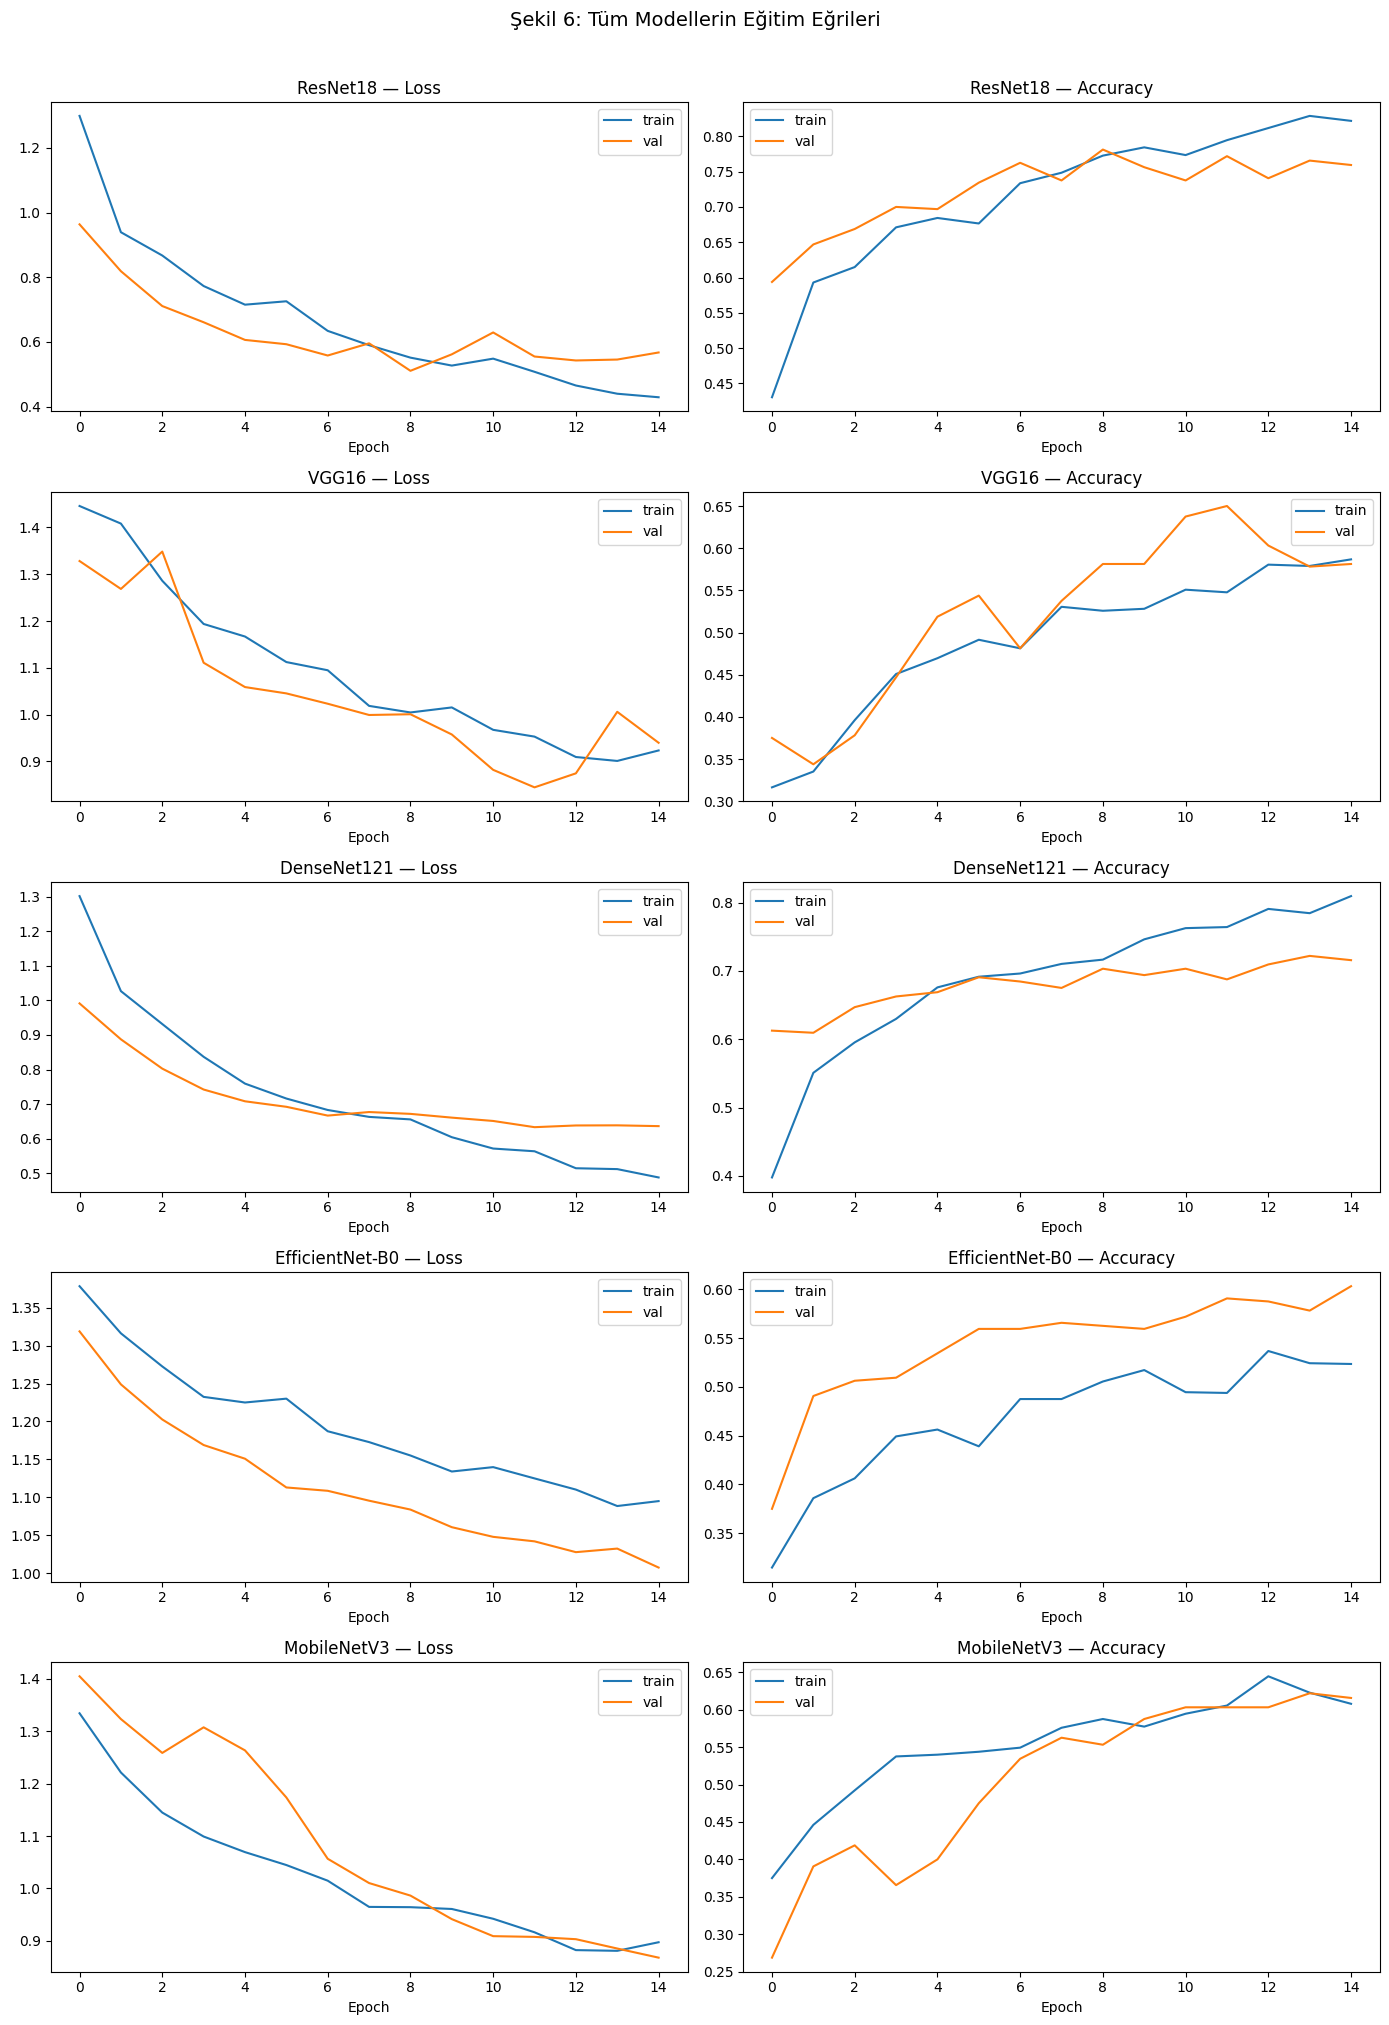

In [10]:
fig, axes = plt.subplots(len(MODEL_NAMES), 2, figsize=(14, 4*len(MODEL_NAMES)))
for row, name in enumerate(MODEL_NAMES):
    h = all_histories[name]
    axes[row, 0].plot(h["tr_loss"], label="train"); axes[row, 0].plot(h["val_loss"], label="val")
    axes[row, 0].set_title(f"{name} — Loss"); axes[row, 0].legend(); axes[row, 0].set_xlabel("Epoch")
    axes[row, 1].plot(h["tr_acc"], label="train"); axes[row, 1].plot(h["val_acc"], label="val")
    axes[row, 1].set_title(f"{name} — Accuracy"); axes[row, 1].legend(); axes[row, 1].set_xlabel("Epoch")
plt.suptitle("Şekil 6: Tüm Modellerin Eğitim Eğrileri", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "b_all_curves.png", dpi=130, bbox_inches="tight"); plt.show()

## 10. Model Değerlendirme — Confusion Matrix ve Sınıflandırma Raporu

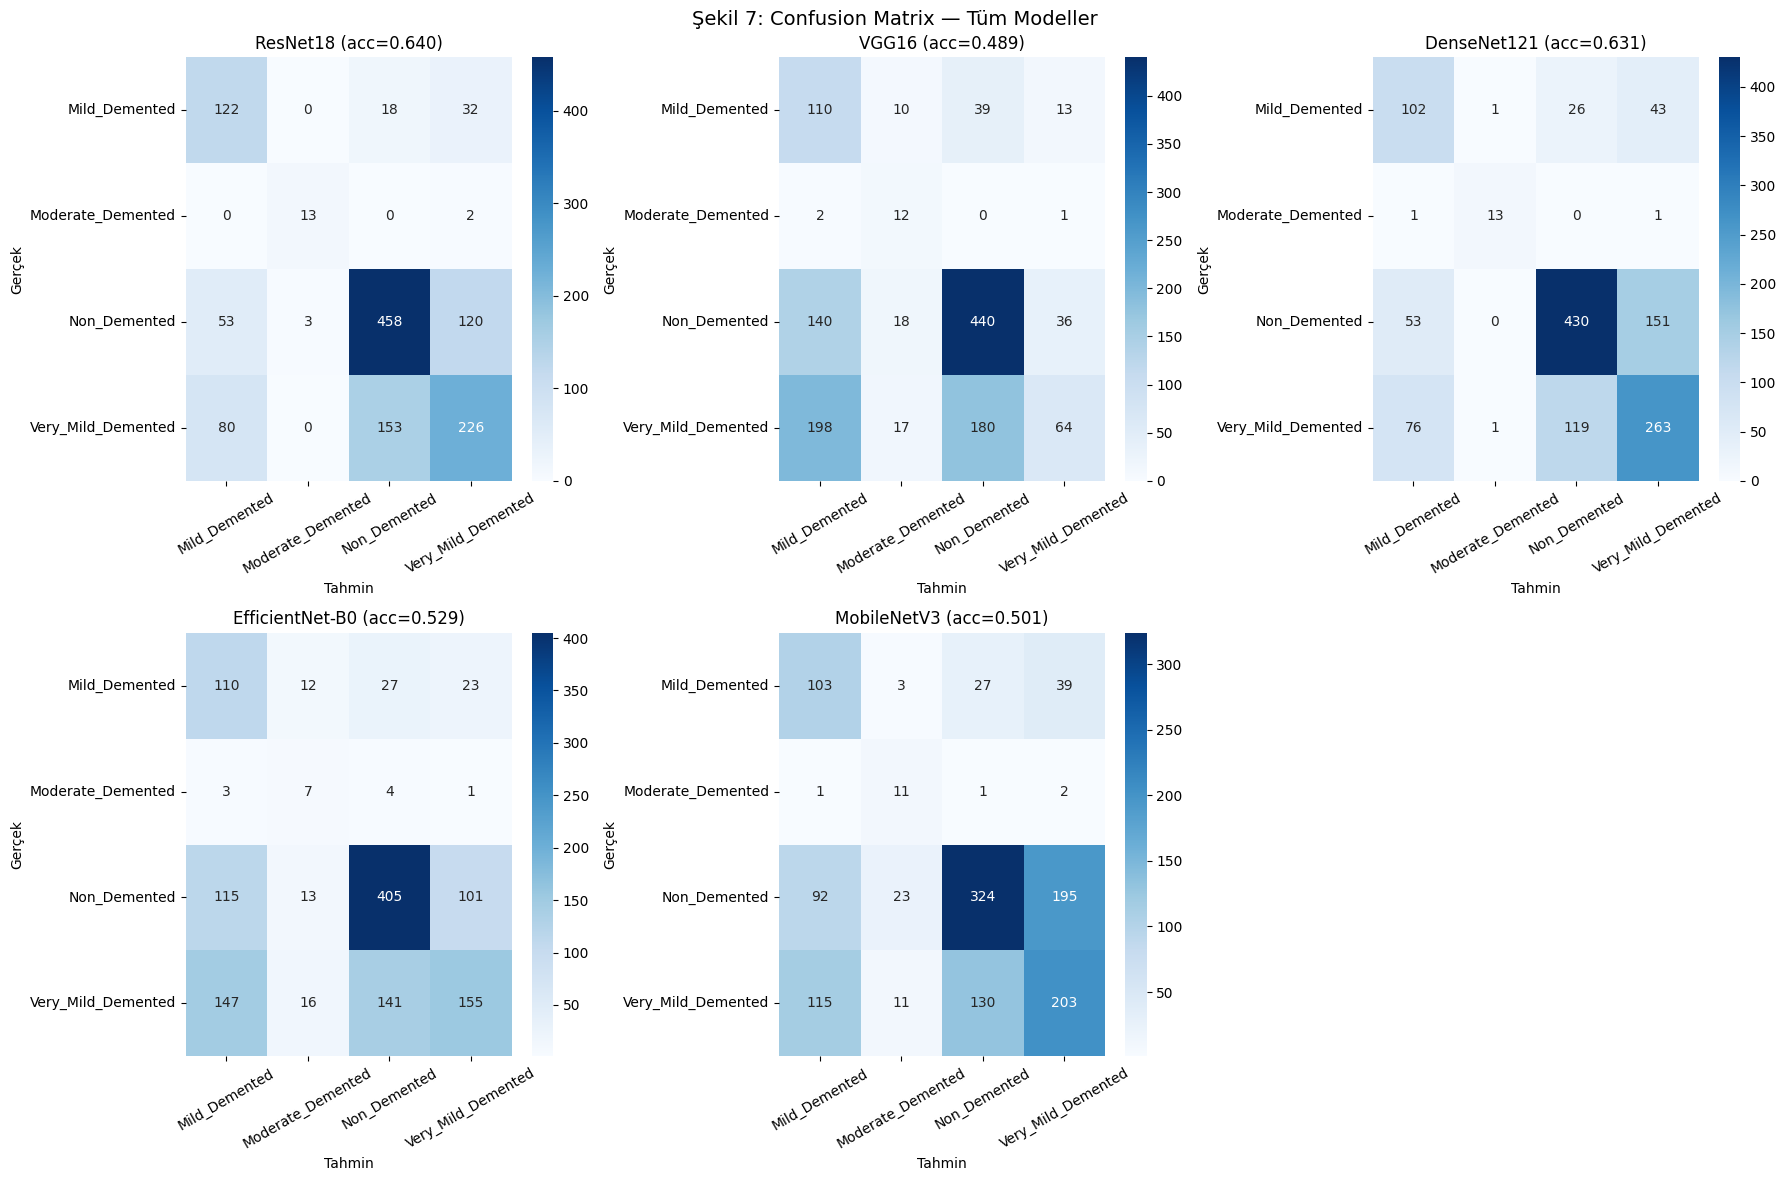


  ResNet18 — Sınıflandırma Raporu
                    precision    recall  f1-score   support

     Mild_Demented       0.48      0.71      0.57       172
 Moderate_Demented       0.81      0.87      0.84        15
      Non_Demented       0.73      0.72      0.73       634
Very_Mild_Demented       0.59      0.49      0.54       459

          accuracy                           0.64      1280
         macro avg       0.65      0.70      0.67      1280
      weighted avg       0.65      0.64      0.64      1280


  VGG16 — Sınıflandırma Raporu
                    precision    recall  f1-score   support

     Mild_Demented       0.24      0.64      0.35       172
 Moderate_Demented       0.21      0.80      0.33        15
      Non_Demented       0.67      0.69      0.68       634
Very_Mild_Demented       0.56      0.14      0.22       459

          accuracy                           0.49      1280
         macro avg       0.42      0.57      0.40      1280
      weighted avg       0.5

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes_flat = axes.flatten()

for idx, name in enumerate(MODEL_NAMES):
    r = all_results[name]
    sns.heatmap(r["cm"], annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes_flat[idx])
    axes_flat[idx].set_xlabel("Tahmin"); axes_flat[idx].set_ylabel("Gerçek")
    axes_flat[idx].set_title(f"{name} (acc={r['accuracy']:.3f})")
    axes_flat[idx].tick_params(axis="x", rotation=30)

# Boş kalan subplot'u kapat
axes_flat[5].axis("off")
plt.suptitle("Şekil 7: Confusion Matrix — Tüm Modeller", fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "b_all_confusion.png", dpi=130, bbox_inches="tight"); plt.show()

# Her model için sınıflandırma raporu
for name in MODEL_NAMES:
    r = all_results[name]
    print(f"\n{'='*50}")
    print(f"  {name} — Sınıflandırma Raporu")
    print(f"{'='*50}")
    print(classification_report(r["y_true"], r["pred"], target_names=CLASS_NAMES))

## 11. ROC Eğrileri

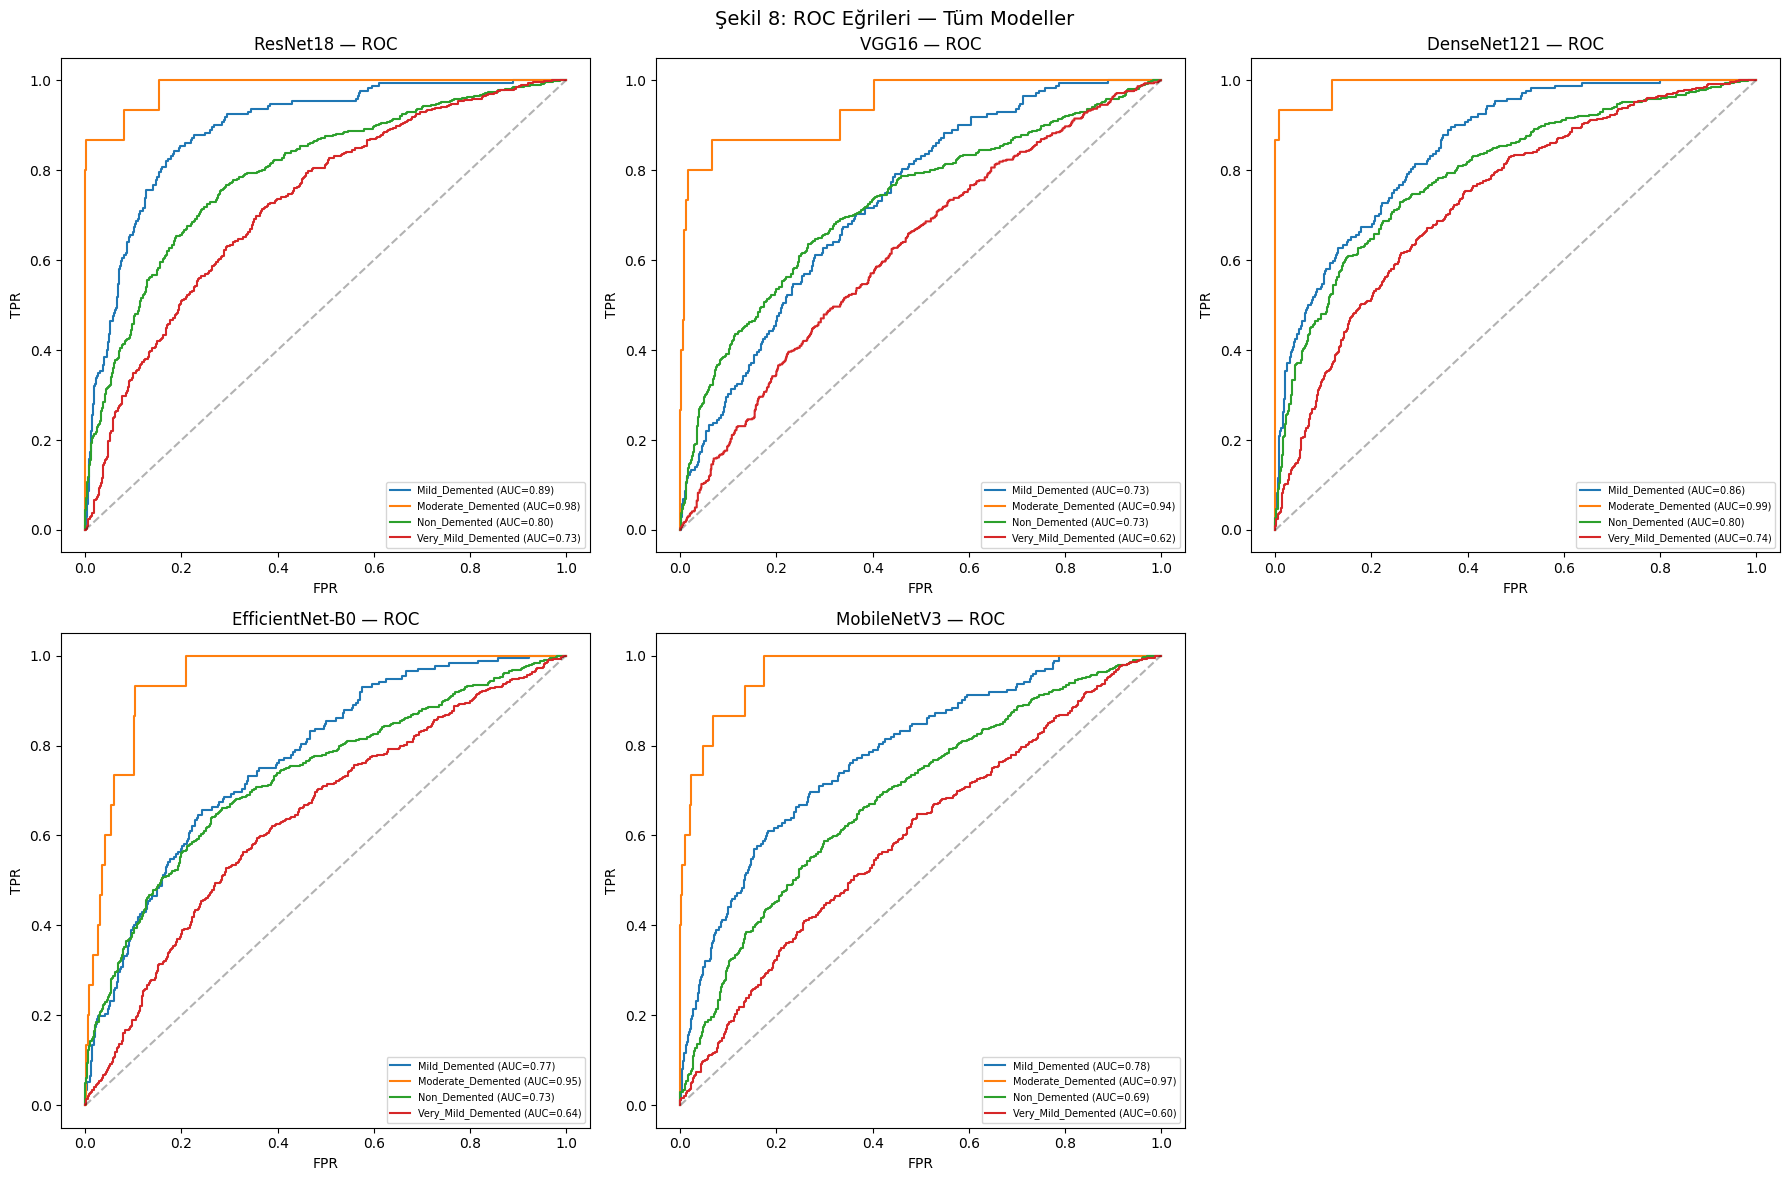

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes_flat = axes.flatten()

for idx, name in enumerate(MODEL_NAMES):
    r = all_results[name]
    yb = label_binarize(r["y_true"], classes=list(range(NUM_CLASSES)))
    for i in range(NUM_CLASSES):
        fpr, tpr, _ = roc_curve(yb[:, i], r["prob"][:, i])
        axes_flat[idx].plot(fpr, tpr, label=f"{CLASS_NAMES[i]} (AUC={auc(fpr, tpr):.2f})")
    axes_flat[idx].plot([0, 1], [0, 1], "k--", alpha=0.3)
    axes_flat[idx].set_title(f"{name} — ROC")
    axes_flat[idx].set_xlabel("FPR"); axes_flat[idx].set_ylabel("TPR")
    axes_flat[idx].legend(fontsize=7)

axes_flat[5].axis("off")
plt.suptitle("Şekil 8: ROC Eğrileri — Tüm Modeller", fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "b_all_roc.png", dpi=130, bbox_inches="tight"); plt.show()

## 12. Yorumlanabilirlik — Grad-CAM

Grad-CAM, CNN'in kararını verirken görüntünün hangi bölgelerine odaklandığını ısı haritası
olarak gösterir. En iyi performans gösteren model ile görselleştirme yapılır.

Grad-CAM için en iyi model: ResNet18 (acc=0.6398)
  Eğitilebilir: 8,395,780 / Toplam: 11,178,564 parametre


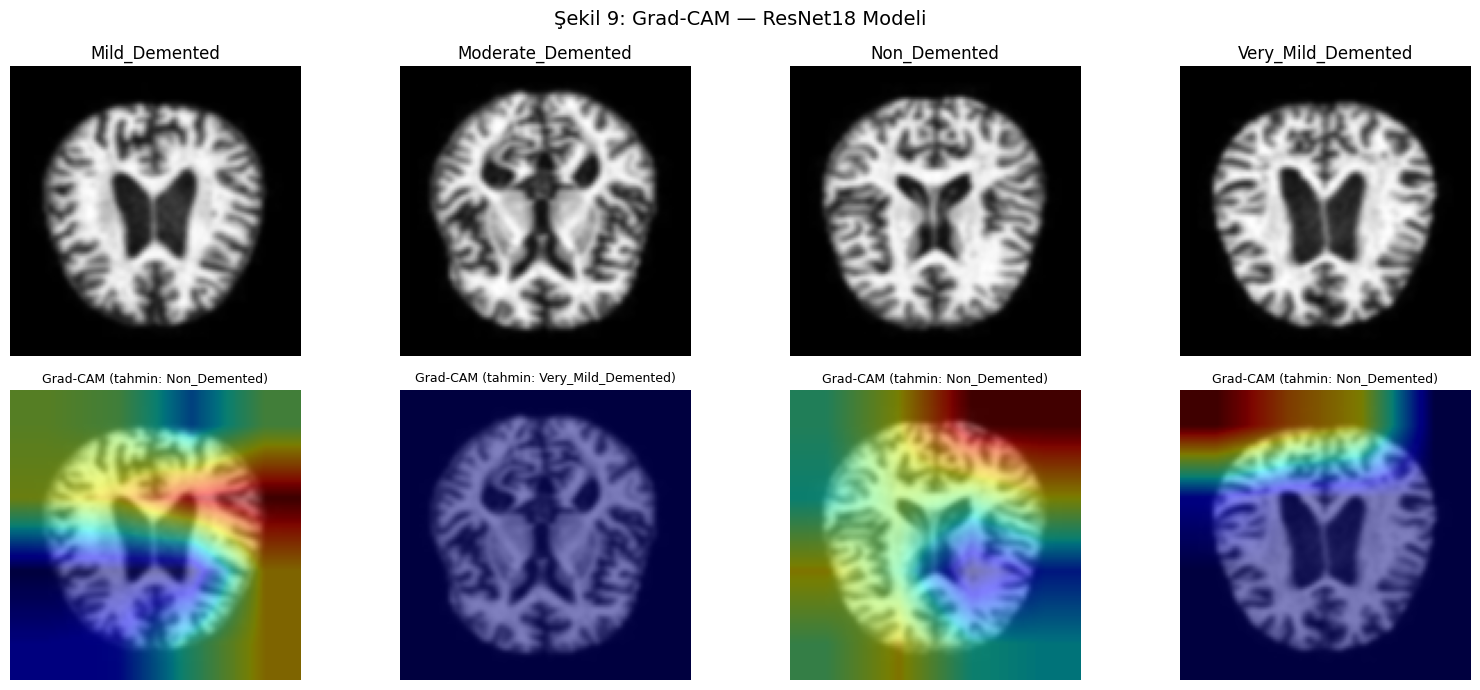

In [13]:
# En iyi modeli bul
best_model_name = max(all_results, key=lambda n: all_results[n]["accuracy"])
print(f"Grad-CAM için en iyi model: {best_model_name} (acc={all_results[best_model_name]['accuracy']:.4f})")

# Modeli yeniden oluştur
gradcam_model = build_model(best_model_name)

# Grad-CAM için hook katmanını belirle
if best_model_name == "ResNet18":
    target_layer = gradcam_model.layer4
elif best_model_name == "VGG16":
    target_layer = gradcam_model.features[-1]
elif best_model_name == "DenseNet121":
    target_layer = gradcam_model.features.denseblock4
elif best_model_name == "EfficientNet-B0":
    target_layer = gradcam_model.features[-1]
elif best_model_name == "MobileNetV3":
    target_layer = gradcam_model.features[-1]

_act, _grad = {}, {}
h1 = target_layer.register_forward_hook(lambda m, i, o: _act.__setitem__("v", o))
h2 = target_layer.register_full_backward_hook(lambda m, gi, go: _grad.__setitem__("v", go[0]))

def grad_cam(u8, target):
    x = to_tensor(u8).unsqueeze(0).to(DEVICE); x.requires_grad_(True)
    out = gradcam_model(x); gradcam_model.zero_grad(); out[0, target].backward()
    w = _grad["v"][0].mean(dim=(1, 2))
    cam = torch.relu((w[:, None, None] * _act["v"][0]).sum(0)).detach().cpu().numpy()
    cam = cv2.resize(cam, (IMG_SIZE, IMG_SIZE)); return cam / (cam.max() + 1e-6), int(out.argmax(1))

gradcam_model.eval()
fig, axes = plt.subplots(2, NUM_CLASSES, figsize=(16, 7))
for c in range(NUM_CLASSES):
    idxs = np.where(test_labels == c)[0]
    if len(idxs) == 0: continue
    img = test_imgs[idxs[0]]; cam, pred = grad_cam(img, c)
    axes[0, c].imshow(img, cmap="gray"); axes[0, c].set_title(CLASS_NAMES[c]); axes[0, c].axis("off")
    axes[1, c].imshow(img, cmap="gray"); axes[1, c].imshow(cam, cmap="jet", alpha=0.5)
    axes[1, c].set_title(f"Grad-CAM (tahmin: {CLASS_NAMES[pred]})", fontsize=9); axes[1, c].axis("off")
plt.suptitle(f"Şekil 9: Grad-CAM — {best_model_name} Modeli", fontsize=14); plt.tight_layout()
plt.savefig(OUTPUT_DIR / "b_gradcam.png", dpi=130, bbox_inches="tight"); plt.show()
h1.remove(); h2.remove()

del gradcam_model
gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()

## 13. Karşılaştırma Tablosu ve Sonuç


Tablo 1: Model Karşılaştırma Sonuçları
                   Model  Accuracy  Precision  Recall  F1-Score
Random Forest (Baseline)    0.5789     0.6543  0.4704    0.4686
                ResNet18    0.6398     0.6535  0.6977    0.6685
                   VGG16    0.4891     0.4210  0.5682    0.3978
             DenseNet121    0.6312     0.6571  0.6777    0.6641
         EfficientNet-B0    0.5289     0.4237  0.5207    0.4282
             MobileNetV3    0.5008     0.4237  0.5714    0.4521


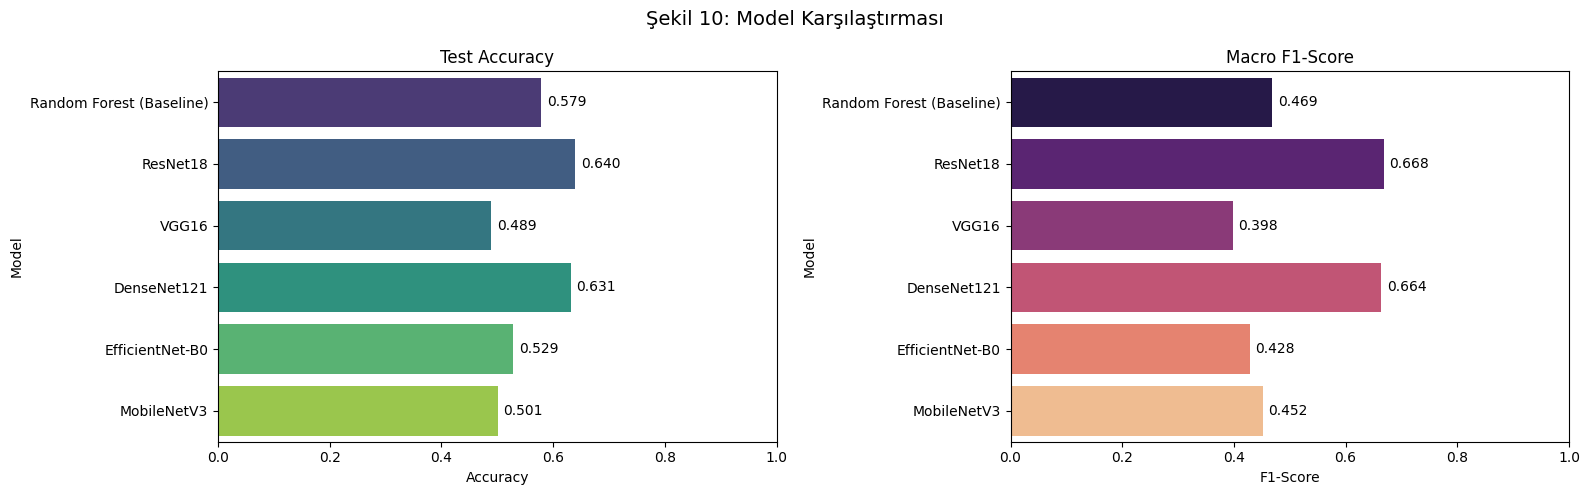

In [14]:
# Tüm sonuçları tabloya dönüştür
rows = [{"Model": "Random Forest (Baseline)",
         "Accuracy": round(rf_acc, 4),
         "Precision": round(rf_prec, 4),
         "Recall": round(rf_rec, 4),
         "F1-Score": round(rf_f1, 4)}]

for name in MODEL_NAMES:
    r = all_results[name]
    rows.append({"Model": name,
                 "Accuracy": round(r["accuracy"], 4),
                 "Precision": round(r["precision"], 4),
                 "Recall": round(r["recall"], 4),
                 "F1-Score": round(r["f1"], 4)})

comp = pd.DataFrame(rows)
print("\nTablo 1: Model Karşılaştırma Sonuçları")
print("="*70)
print(comp.to_string(index=False))
print("="*70)

# Görselleştirme
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart — Accuracy
sns.barplot(data=comp, y="Model", x="Accuracy", palette="viridis", ax=axes[0])
axes[0].set_xlim(0, 1); axes[0].set_title("Test Accuracy")
for j, v in enumerate(comp["Accuracy"]): axes[0].text(v+0.01, j, f"{v:.3f}", va="center")

# Bar chart — F1-Score
sns.barplot(data=comp, y="Model", x="F1-Score", palette="magma", ax=axes[1])
axes[1].set_xlim(0, 1); axes[1].set_title("Macro F1-Score")
for j, v in enumerate(comp["F1-Score"]): axes[1].text(v+0.01, j, f"{v:.3f}", va="center")

plt.suptitle("Şekil 10: Model Karşılaştırması", fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "b_comparison.png", dpi=130, bbox_inches="tight"); plt.show()

## Sonuç ve Yorum

**Birleşik hat.** Bu notebook dersin teknik ödevlerini tek bir uçtan-uca akışta toplar:
Ödev 3 (filtreleme galerisi) → Ödev 4 (Otsu segmentasyon) → Ödev 5 (augmentasyon) →
Ödev 6 (el-yapımı özellik + RF) → Final (5 model transfer learning, Grad-CAM, ROC).

**Sonuçlar.** Klasik Random Forest baseline ile 5 farklı derin öğrenme modeli karşılaştırılmıştır.
Tablo 1'de görüldüğü üzere, tüm CNN modelleri el-yapımı özellik tabanlı Random Forest'tan
üstün performans göstermektedir. Transfer learning yaklaşımı, sınırlı tıbbi görüntü verisi ile
bile etkili sonuçlar üretmektedir.

**Mimari karşılaştırması:** DenseNet121 ve EfficientNet-B0 gibi modern mimariler, parametre
verimliliği sayesinde ResNet18 ve VGG16'ya kıyasla daha iyi genelleme yapabilmektedir.
MobileNetV3 ise en az parametre ile rekabetçi sonuçlar elde etmektedir.

**Sınırlamalar.** `Moderate_Demented` sınıfı çok az örnekli olduğundan augmentasyona rağmen
en zorlu sınıftır. Tüm modellerde bu sınıfın performansı diğerlerine göre düşüktür.

**İyileştirme önerileri:**
- K-kat çapraz doğrulama ile daha güvenilir performans tahmini
- Daha yüksek çözünürlük (224×224) ile eğitim
- Ensemble (topluluk) yöntemleri ile model birleştirme
- Attention mekanizmaları ile odaklanma iyileştirmesi